# Region Topic Analysis

This tutorial covers topic modeling analysis with TF-MInDi:
- Running topic modeling on regions using {func}`~tfmindi.tl.run_topic_modeling`
- Evaluating different topic numbers with {func}`~tfmindi.tl.evaluate_topic_models`
- Analyzing topic-cluster and topic-DBD relationships
- Visualizing topics in t-SNE space and heatmaps

In [1]:
import tfmindi as tm

DATA_DIR = "../../../../data/tfmindi/"

In [3]:
# Load clustered data from previous tutorial
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

## Running Topic Modeling

Topic modeling helps discover co-occurring TF binding patterns across genomic regions. We use {func}`~tfmindi.tl.run_topic_modeling` which applies Latent Dirichlet Allocation (LDA) to find topics based on seqlet cluster compositions.

Each region gets a topic probability distribution, and each topic represents a pattern of co-occurring TF binding clusters.

In [8]:
# Run topic modeling with 15 topics
model, region_topic, count_table = tm.tl.run_topic_modeling(adata, n_topics=15, random_state=42)

Filtered 0 seqlets with unknown DBD annotations
Using 1007193 deduplicated seqlets across 36778 regions


2025-09-03 16:31:53 | [INFO] n_documents: 36778
2025-09-03 16:31:53 | [INFO] vocab_size: 84
2025-09-03 16:31:53 | [INFO] n_words: 1007193
2025-09-03 16:31:53 | [INFO] n_topics: 15
2025-09-03 16:31:53 | [INFO] n_iter: 150


Count matrix shape: (36778, 84) (regions × clusters)
Fitting LDA model with 15 topics...


2025-09-03 16:31:54 | [INFO] <0> log likelihood: -6981388
2025-09-03 16:31:56 | [INFO] <10> log likelihood: -6817059
2025-09-03 16:31:57 | [INFO] <20> log likelihood: -6687740
2025-09-03 16:31:59 | [INFO] <30> log likelihood: -6220117
2025-09-03 16:32:01 | [INFO] <40> log likelihood: -5737833
2025-09-03 16:32:03 | [INFO] <50> log likelihood: -5358322
2025-09-03 16:32:05 | [INFO] <60> log likelihood: -5107999
2025-09-03 16:32:06 | [INFO] <70> log likelihood: -4954173
2025-09-03 16:32:08 | [INFO] <80> log likelihood: -4858821
2025-09-03 16:32:10 | [INFO] <90> log likelihood: -4803264
2025-09-03 16:32:12 | [INFO] <100> log likelihood: -4765943
2025-09-03 16:32:13 | [INFO] <110> log likelihood: -4734091
2025-09-03 16:32:15 | [INFO] <120> log likelihood: -4702546
2025-09-03 16:32:17 | [INFO] <130> log likelihood: -4677716
2025-09-03 16:32:19 | [INFO] <140> log likelihood: -4654304
2025-09-03 16:32:20 | [INFO] <149> log likelihood: -4647687


## Evaluating Topic Numbers

To find the optimal number of topics, use {func}`~tfmindi.tl.evaluate_topic_models`. This tests different topic numbers and provides coherence scores to help choose the best model.

In [15]:
# Evaluate topic models with different numbers of topics
topic_range = [5, 20, 30, 50, 80, 100]
results = tm.tl.evaluate_topic_models(adata, topic_range, random_state=42)

Evaluating 6 different topic models...
Training model with 5 topics...
Filtered 0 seqlets with unknown DBD annotations
Using 1007193 deduplicated seqlets across 36778 regions


2025-09-03 16:39:22 | [INFO] n_documents: 36778
2025-09-03 16:39:22 | [INFO] vocab_size: 84
2025-09-03 16:39:22 | [INFO] n_words: 1007193
2025-09-03 16:39:22 | [INFO] n_topics: 5
2025-09-03 16:39:22 | [INFO] n_iter: 150


Count matrix shape: (36778, 84) (regions × clusters)
Fitting LDA model with 5 topics...


2025-09-03 16:39:23 | [INFO] <0> log likelihood: -5800230
2025-09-03 16:39:24 | [INFO] <10> log likelihood: -5752005
2025-09-03 16:39:25 | [INFO] <20> log likelihood: -5710066
2025-09-03 16:39:25 | [INFO] <30> log likelihood: -5451779
2025-09-03 16:39:26 | [INFO] <40> log likelihood: -5157968
2025-09-03 16:39:27 | [INFO] <50> log likelihood: -4950225
2025-09-03 16:39:28 | [INFO] <60> log likelihood: -4804651
2025-09-03 16:39:29 | [INFO] <70> log likelihood: -4706233
2025-09-03 16:39:30 | [INFO] <80> log likelihood: -4628583
2025-09-03 16:39:31 | [INFO] <90> log likelihood: -4584094
2025-09-03 16:39:31 | [INFO] <100> log likelihood: -4557293
2025-09-03 16:39:32 | [INFO] <110> log likelihood: -4537840
2025-09-03 16:39:33 | [INFO] <120> log likelihood: -4522975
2025-09-03 16:39:34 | [INFO] <130> log likelihood: -4509754
2025-09-03 16:39:35 | [INFO] <140> log likelihood: -4499173
2025-09-03 16:39:36 | [INFO] <149> log likelihood: -4489351


Training model with 20 topics...
Filtered 0 seqlets with unknown DBD annotations
Using 1007193 deduplicated seqlets across 36778 regions


...

Training model with 100 topics...
Filtered 0 seqlets with unknown DBD annotations
Using 1007193 deduplicated seqlets across 36778 regions


2025-09-03 16:44:13 | [INFO] n_documents: 36778
2025-09-03 16:44:13 | [INFO] vocab_size: 84
2025-09-03 16:44:13 | [INFO] n_words: 1007193
2025-09-03 16:44:13 | [INFO] n_topics: 100
2025-09-03 16:44:13 | [INFO] n_iter: 150


Count matrix shape: (36778, 84) (regions × clusters)
Fitting LDA model with 100 topics...


2025-09-03 16:44:14 | [INFO] <0> log likelihood: -9100111
2025-09-03 16:44:23 | [INFO] <10> log likelihood: -8445454
2025-09-03 16:44:32 | [INFO] <20> log likelihood: -7834813
2025-09-03 16:44:40 | [INFO] <30> log likelihood: -7030279
2025-09-03 16:44:49 | [INFO] <40> log likelihood: -6437012
2025-09-03 16:44:57 | [INFO] <50> log likelihood: -6073191
2025-09-03 16:45:05 | [INFO] <60> log likelihood: -5847805
2025-09-03 16:45:14 | [INFO] <70> log likelihood: -5716180
2025-09-03 16:45:22 | [INFO] <80> log likelihood: -5637219
2025-09-03 16:45:31 | [INFO] <90> log likelihood: -5576602
2025-09-03 16:45:39 | [INFO] <100> log likelihood: -5537322
2025-09-03 16:45:47 | [INFO] <110> log likelihood: -5510488
2025-09-03 16:45:56 | [INFO] <120> log likelihood: -5487452
2025-09-03 16:46:04 | [INFO] <130> log likelihood: -5471743
2025-09-03 16:46:12 | [INFO] <140> log likelihood: -5456657
2025-09-03 16:46:21 | [INFO] <149> log likelihood: -5444331


Model with 5 topics: log-likelihood = 801638.40
Model with 20 topics: log-likelihood = 4632357.03
Model with 30 topics: log-likelihood = 5139684.29
Model with 50 topics: log-likelihood = 5142809.23
Model with 80 topics: log-likelihood = 4126012.81
Model with 100 topics: log-likelihood = 3100360.18


In [18]:
# find n topics with highest log likelihood
best_n = max(results, key=results.get)
print(f"Best number of topics: {best_n} with log likelihood {results[best_n]}")

Best number of topics: 50 with log likelihood 5142809.231505942


Based on the LL scores, choose the optimal number of topics and rerun the model if needed.

In [20]:
# Rerun with optimal number of topics if different from 15
model, region_topic, count_table = tm.tl.run_topic_modeling(adata, n_topics=50, random_state=42)

Filtered 0 seqlets with unknown DBD annotations
Using 1007193 deduplicated seqlets across 36778 regions


2025-09-03 16:50:52 | [INFO] n_documents: 36778
2025-09-03 16:50:52 | [INFO] vocab_size: 84
2025-09-03 16:50:52 | [INFO] n_words: 1007193
2025-09-03 16:50:52 | [INFO] n_topics: 50
2025-09-03 16:50:52 | [INFO] n_iter: 150


Count matrix shape: (36778, 84) (regions × clusters)
Fitting LDA model with 50 topics...


2025-09-03 16:50:53 | [INFO] <0> log likelihood: -8364614
2025-09-03 16:50:58 | [INFO] <10> log likelihood: -7906808
2025-09-03 16:51:02 | [INFO] <20> log likelihood: -7463233
2025-09-03 16:51:07 | [INFO] <30> log likelihood: -6775622
2025-09-03 16:51:11 | [INFO] <40> log likelihood: -6206196
2025-09-03 16:51:16 | [INFO] <50> log likelihood: -5768474
2025-09-03 16:51:20 | [INFO] <60> log likelihood: -5480335
2025-09-03 16:51:25 | [INFO] <70> log likelihood: -5309910
2025-09-03 16:51:29 | [INFO] <80> log likelihood: -5197049
2025-09-03 16:51:34 | [INFO] <90> log likelihood: -5119670
2025-09-03 16:51:39 | [INFO] <100> log likelihood: -5071945
2025-09-03 16:51:43 | [INFO] <110> log likelihood: -5038125
2025-09-03 16:51:48 | [INFO] <120> log likelihood: -5009568
2025-09-03 16:51:52 | [INFO] <130> log likelihood: -4993880
2025-09-03 16:51:57 | [INFO] <140> log likelihood: -4989363
2025-09-03 16:52:01 | [INFO] <149> log likelihood: -4978725


## Topic-Cluster Analysis

Analyze which seqlet clusters contribute to each topic using {func}`~tfmindi.tl.get_topic_cluster_matrix`.

In [23]:
# Get topic-cluster relationship matrix
cluster_topic_matrix = tm.tl.get_topic_cluster_matrix(model, count_table)
print(f"Topic-cluster matrix shape: {cluster_topic_matrix.shape}")
cluster_topic_matrix.head()

Topic-cluster matrix shape: (84, 50)


,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,...,Topic_41,Topic_42,Topic_43,Topic_44,Topic_45,Topic_46,Topic_47,Topic_48,Topic_49,Topic_50
0,0.000105,0.000107,0.000737,0.001307,0.000005,0.000005,0.000005,0.000095,0.000005,0.000005,...,0.001210,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005
1,0.000005,0.000005,0.000005,0.001198,0.000056,0.000005,0.000143,0.000005,0.000351,0.000317,...,0.000058,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005
2,0.002506,0.000005,0.000054,0.017140,0.088397,0.000005,0.000005,0.177455,0.000005,0.000005,...,0.033221,0.063654,0.068911,0.000005,0.000005,0.000005,0.000005,0.000005,0.001664,0.000005
3,0.208726,0.000005,0.000005,0.000005,0.007486,0.240454,0.000005,0.022974,0.000153,0.045096,...,0.000005,0.000005,0.070914,0.003990,0.000005,0.000454,0.000005,0.000264,0.047738,0.000005
4,0.001806,0.001382,0.000005,0.042679,0.000005,0.000005,0.000051,0.000005,0.000005,0.000005,...,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.477375


## Visualizing Topics

### DBD-Topic Heatmap

Visualize the relationship between topics and DNA-binding domains using {func}`~tfmindi.pl.dbd_topic_heatmap`.
This shows us which DBDs often co-occur.  

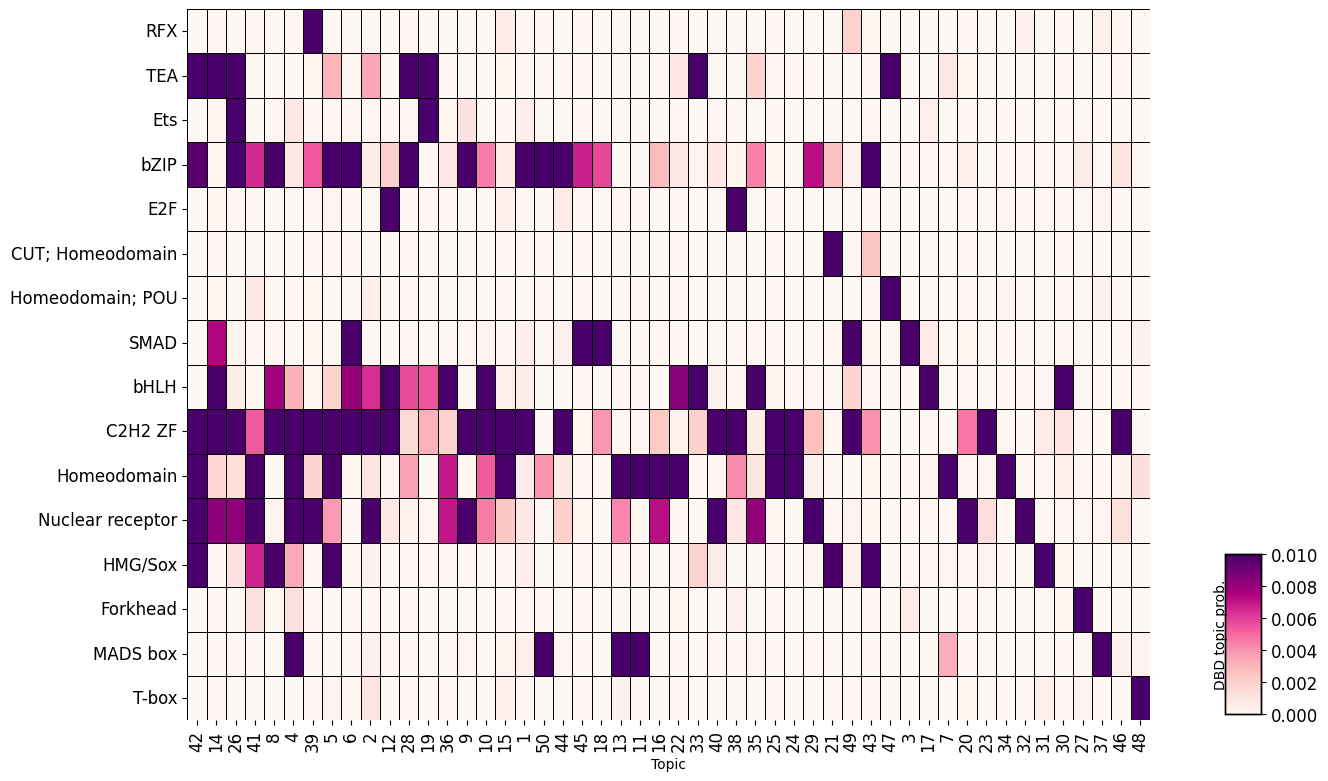

In [26]:
%matplotlib inline
tm.pl.dbd_topic_heatmap(
    adata,
    cluster_topic_matrix,
    width=12,
    height=8,
    x_label_rotation=90,
)

### Topic Visualization in t-SNE Space

Plot t-SNE visualization of regions colored by topic probabilities using {func}`~tfmindi.pl.region_topic_tsne`.

Computing t-SNE coordinates from region-topic matrix...


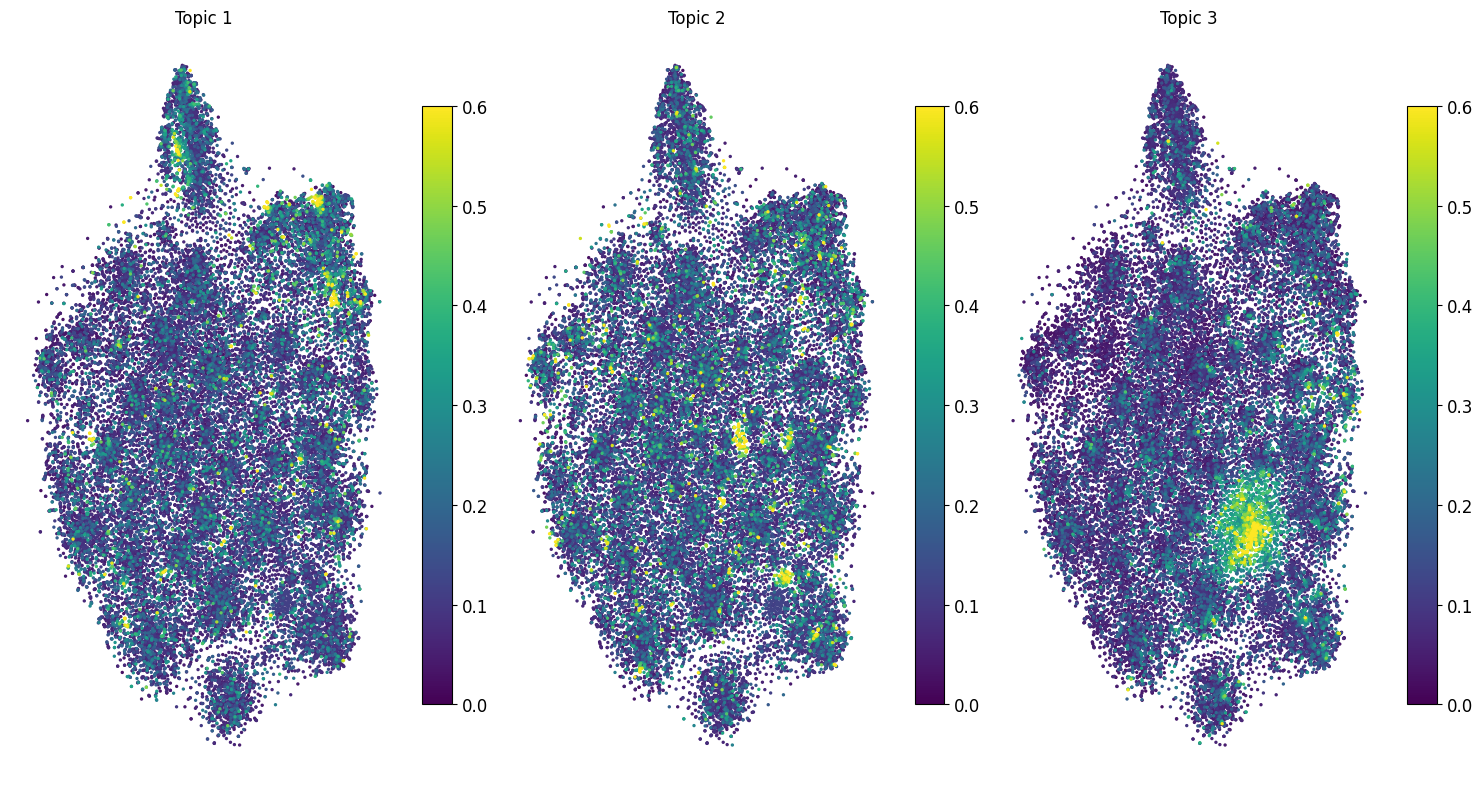

In [35]:
# Plot regions colored by dominant topic
tm.pl.region_topic_tsne(region_topic, topics_to_show=["Topic_1", "Topic_2", "Topic_3"], ncols=3, width=15)